In [1]:
# System and path configuration
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
# Add parent directory to path for module imports
sys.path.insert(0, os.path.abspath('../..'))

# Core LSD imports
from codes.lsd_train import LSD
from codes.utils import (
    plot_random_walks,
    cross_boundary_correctness,
)
from codes.config import LSDConfig

# Scientific computing
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Deep learning
import torch
import torch.nn as nn
import pyro

# Single-cell analysis
import scanpy as sc
import scvelo as scv
import cellrank as cr
from cellrank.kernels import ConnectivityKernel
from cellrank.kernels.utils import TmatProjection

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mean

# Configure matplotlib for better output
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['svg.fonttype'] = 'none'  # Use text instead of paths for fonts
sns.set_style('white')
sns.set_palette('husl')

print("Environment configured successfully!")
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"Scanpy version: {sc.__version__}")

Environment configured successfully!
Python version: 3.8.10
PyTorch version: 2.4.1+cu121
Scanpy version: 1.9.8


In [2]:
# Configure computational device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Check GPU details if available
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
pyro.set_rng_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Using device: cuda:0
GPU Name: NVIDIA GeForce RTX 3090
GPU Memory: 25.44 GB
CUDA Version: 12.1


In [3]:
# Load preprocessed pancreas data with prior pseudotime
print("Loading Hematopoiesis dataset...")
data_path = "../../data/BoneMarrow/normalized_before_low.h5ad"
adata = sc.read(data_path)

print("Dataset loaded successfully!")
print(f"Data path: {data_path}")
print(f"Number of cells: {adata.n_obs:,}")
print(f"Number of genes: {adata.n_vars:,}")
print(f"\nAvailable data layers: {list(adata.layers.keys())}")
print(f"Cell metadata columns: {list(adata.obs.columns)}")
print(f"Cell-cell matrices: {list(adata.obsp.keys())}")

# Display cell type distribution
print(f"\nCell type distribution:")
print("="*50)
cluster_counts = adata.obs['clusters'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = (count / adata.n_obs) * 100
    print(f"  {cluster:15s}: {count:5,} cells ({percentage:5.1f}%)")

# Check for prior information
if 'prior_time' in adata.obs.columns:
    print(f"\nPrior pseudotime available: {adata.obs['prior_time'].notna().sum()} cells have values")
    print(f"  Min: {adata.obs['prior_time'].min():.3f}")
    print(f"  Max: {adata.obs['prior_time'].max():.3f}")

Loading Hematopoiesis dataset...
Dataset loaded successfully!
Data path: ../../data/BoneMarrow/normalized_before_low.h5ad
Number of cells: 5,292
Number of genes: 2,000

Available data layers: ['raw', 'spliced', 'unspliced']
Cell metadata columns: ['clusters', 'palantir_pseudotime', 'librarysize']
Cell-cell matrices: ['connectivities', 'distances']

Cell type distribution:
  HSC_1          : 1,118 cells ( 21.1%)
  HSC_2          :   984 cells ( 18.6%)
  Ery_1          :   742 cells ( 14.0%)
  Mono_1         :   724 cells ( 13.7%)
  Precursors     :   666 cells ( 12.6%)
  Mono_2         :   429 cells (  8.1%)
  DCs            :   303 cells (  5.7%)
  Ery_2          :   265 cells (  5.0%)
  Mega           :    61 cells (  1.2%)


In [4]:
cfg = LSDConfig()

cfg.optimizer.kl_schedule.af = 2
cfg.walks.batch_size = 256
cfg.walks.path_len = 10
cfg.walks.num_walks = 4096
cfg.walks.random_state = SEED

print("Initializing LSD model with dataclass config...")
lsd = LSD(
    adata,
    cfg,
    device=device,
    lib_size_key="librarysize",
    raw_count_key="raw"
)
print("\n✓ Model initialized successfully!")
print(f"  Latent dimension (z): {lsd.z_dim}")
print(f"  Differentiation dimension (B): {lsd.B_dim}")
print(f"  Potential regularization: {lsd.lsd.V_coeff}")
print(f"  Device: {lsd.device}")


Initializing LSD model with dataclass config...

✓ Model initialized successfully!
  Latent dimension (z): 10
  Differentiation dimension (B): 2
  Potential regularization: 0.01
  Device: cuda:0


In [5]:
lsd.set_prior_transition(prior_time_key="palantir_pseudotime")
print("✓ Prior transition matrix incorporated")
print(f"  Cells with prior time: {adata.obs['palantir_pseudotime'].notna().sum()}")


[LSD] Prior transition matrix set from pseudotime and connectivities.
✓ Prior transition matrix incorporated
  Cells with prior time: 5292


Generating 4096 random walk trajectories...
This samples continuous paths through the cell state manifold

✓ Random walks generated successfully!
  Walk tensor shape: torch.Size([4096, 10])
  Each walk: 10 steps through cell neighbors

Visualizing random walks on t-SNE...


/projects/apour/NDE311/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


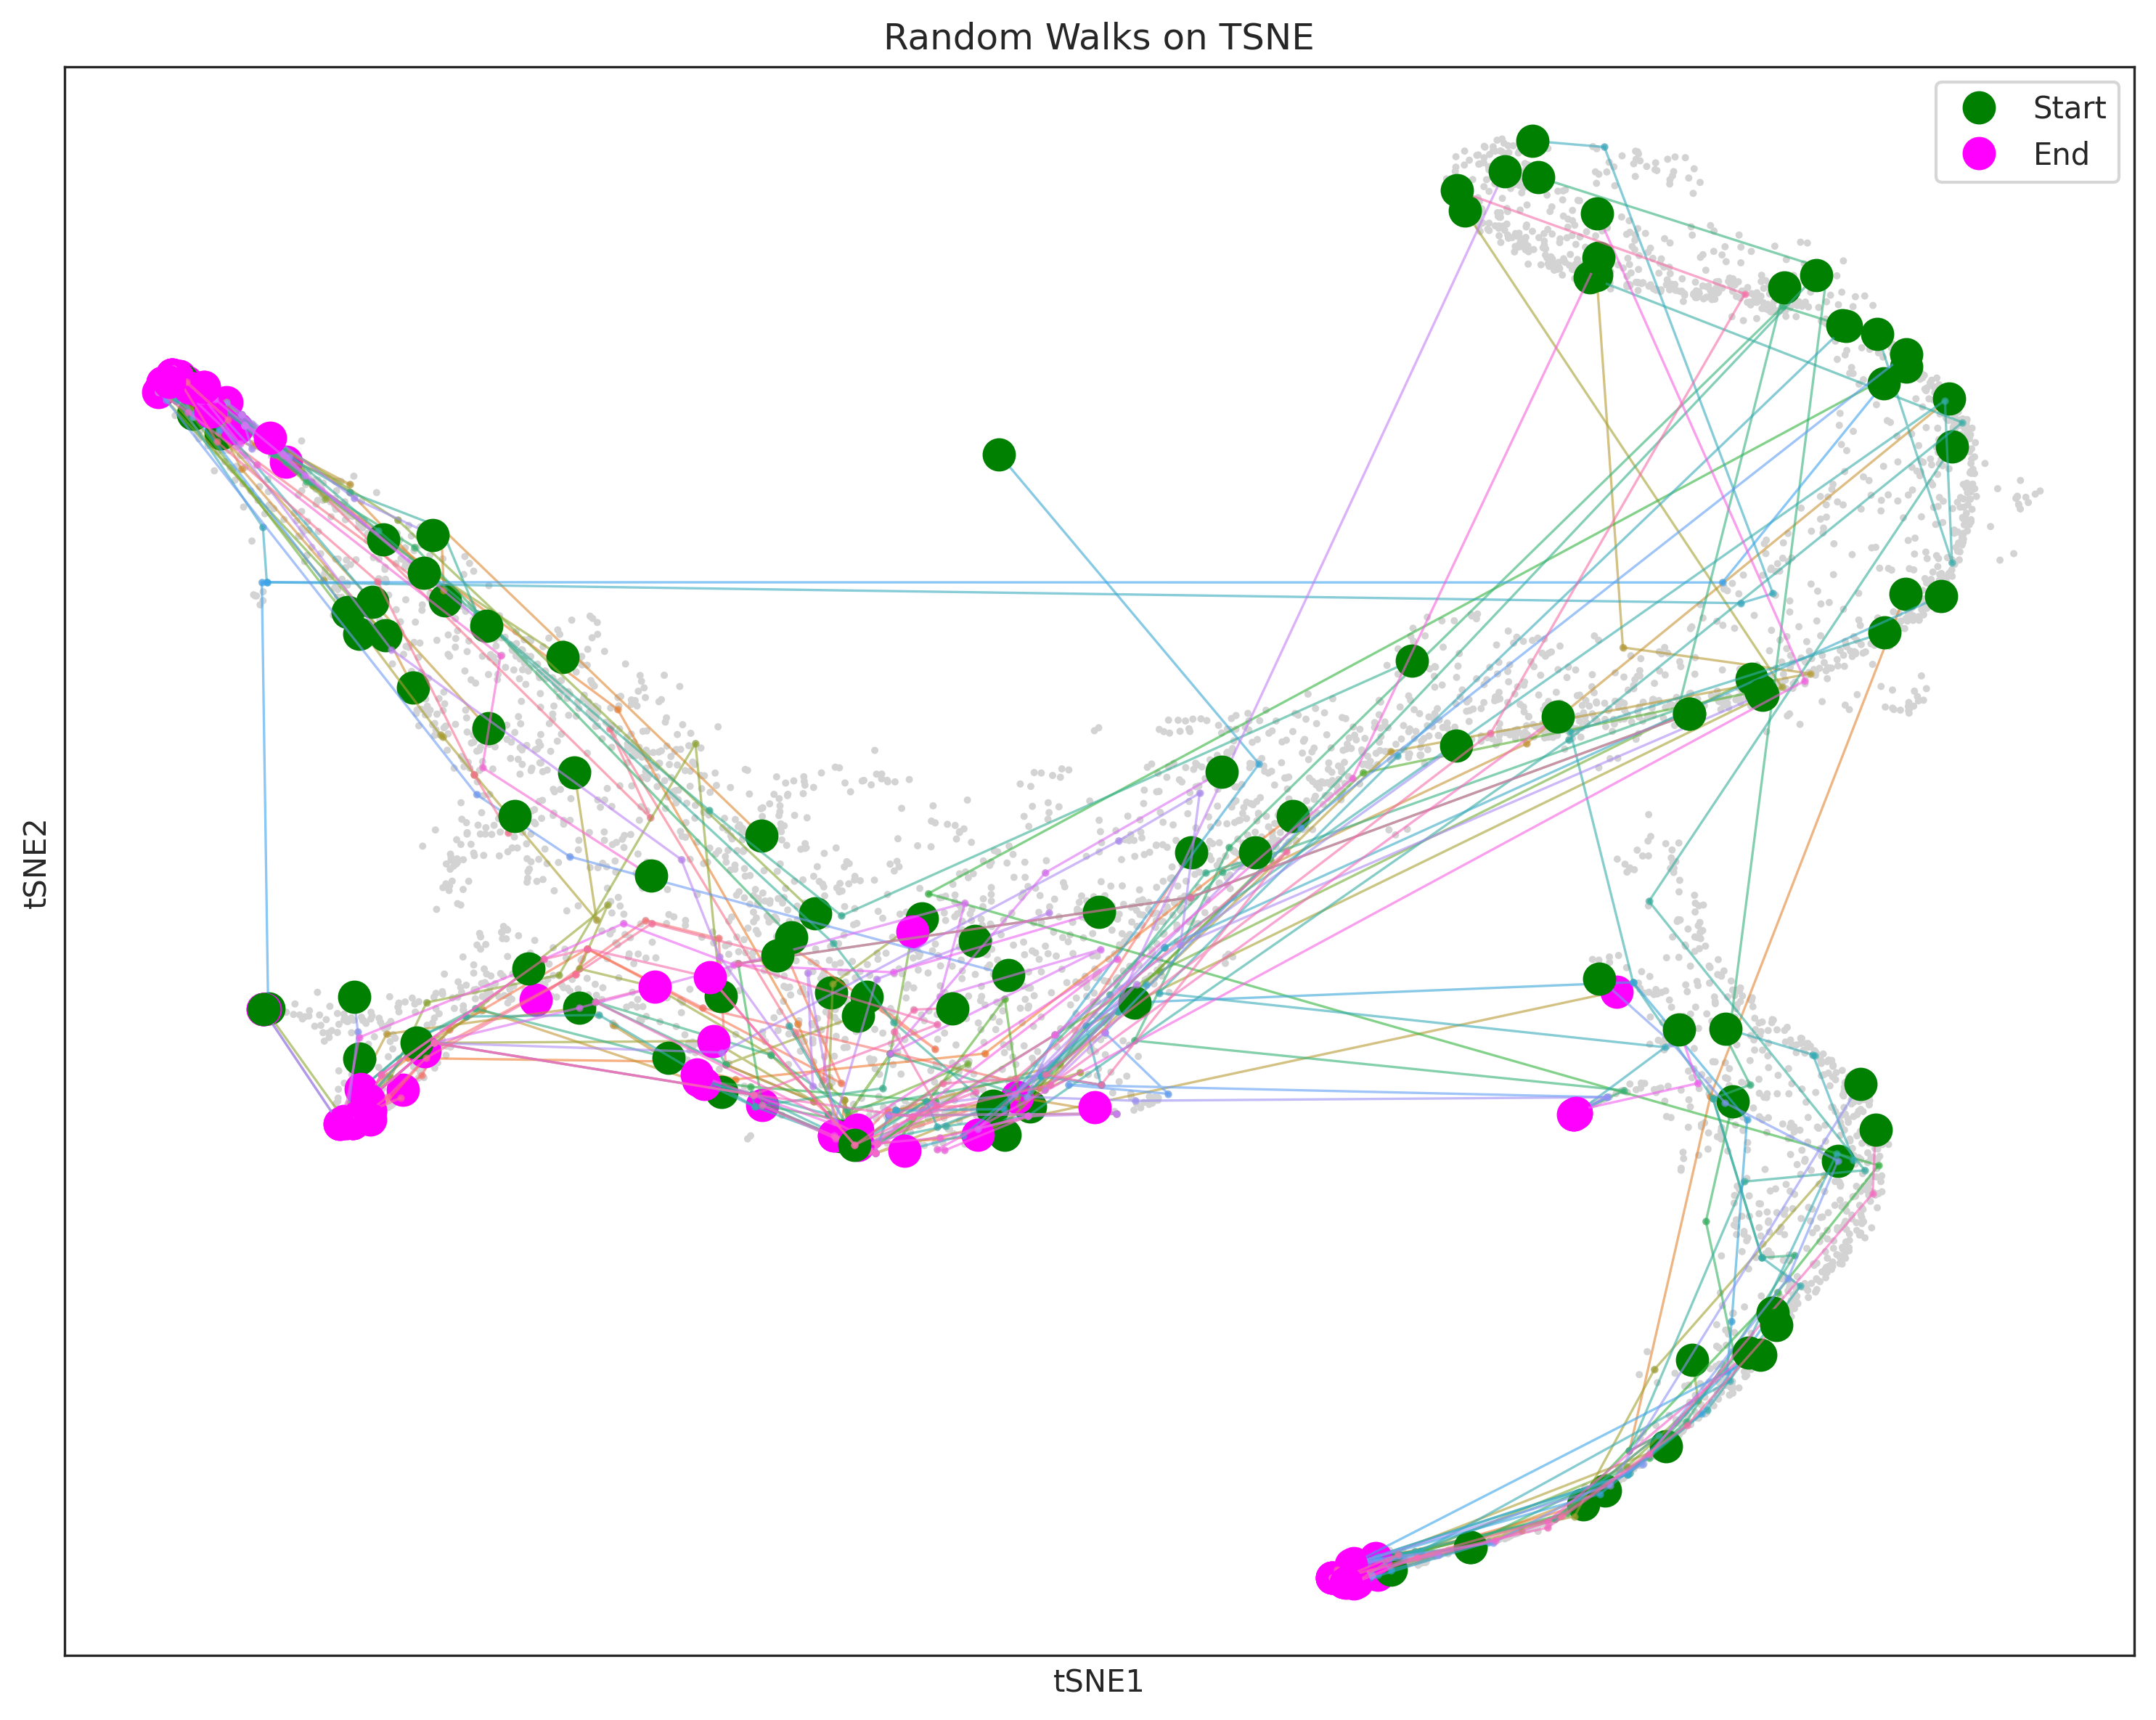

In [6]:
# Generate random walks for training
n_walks = cfg.walks.num_walks
n_steps = cfg.walks.path_len
print(f"Generating {n_walks} random walk trajectories...")
print("This samples continuous paths through the cell state manifold")

# Prepare walks on the cell connectivity graph
lsd.prepare_walks()

print(f"\n✓ Random walks generated successfully!")
print(f"  Walk tensor shape: {lsd.walks.shape}")
print(f"  Each walk: {n_steps} steps through cell neighbors")


# Visualize a subset of random walks
if "X_tsne" in lsd.adata.obsm:
    print("\nVisualizing random walks on t-SNE...")
    plot_random_walks(lsd.adata, lsd.walks[:100], "X_tsne")  # Show first 100 walks


Starting model training...
Training for 200 epochs
This may take 20-30 minutes on GPU...


Training Epochs: 100%|██████████| 200/200 [52:05<00:00, 15.63s/it, -ELBO=0.6247, Potential Metric=0.1067, Entropy Metric=0.0348]


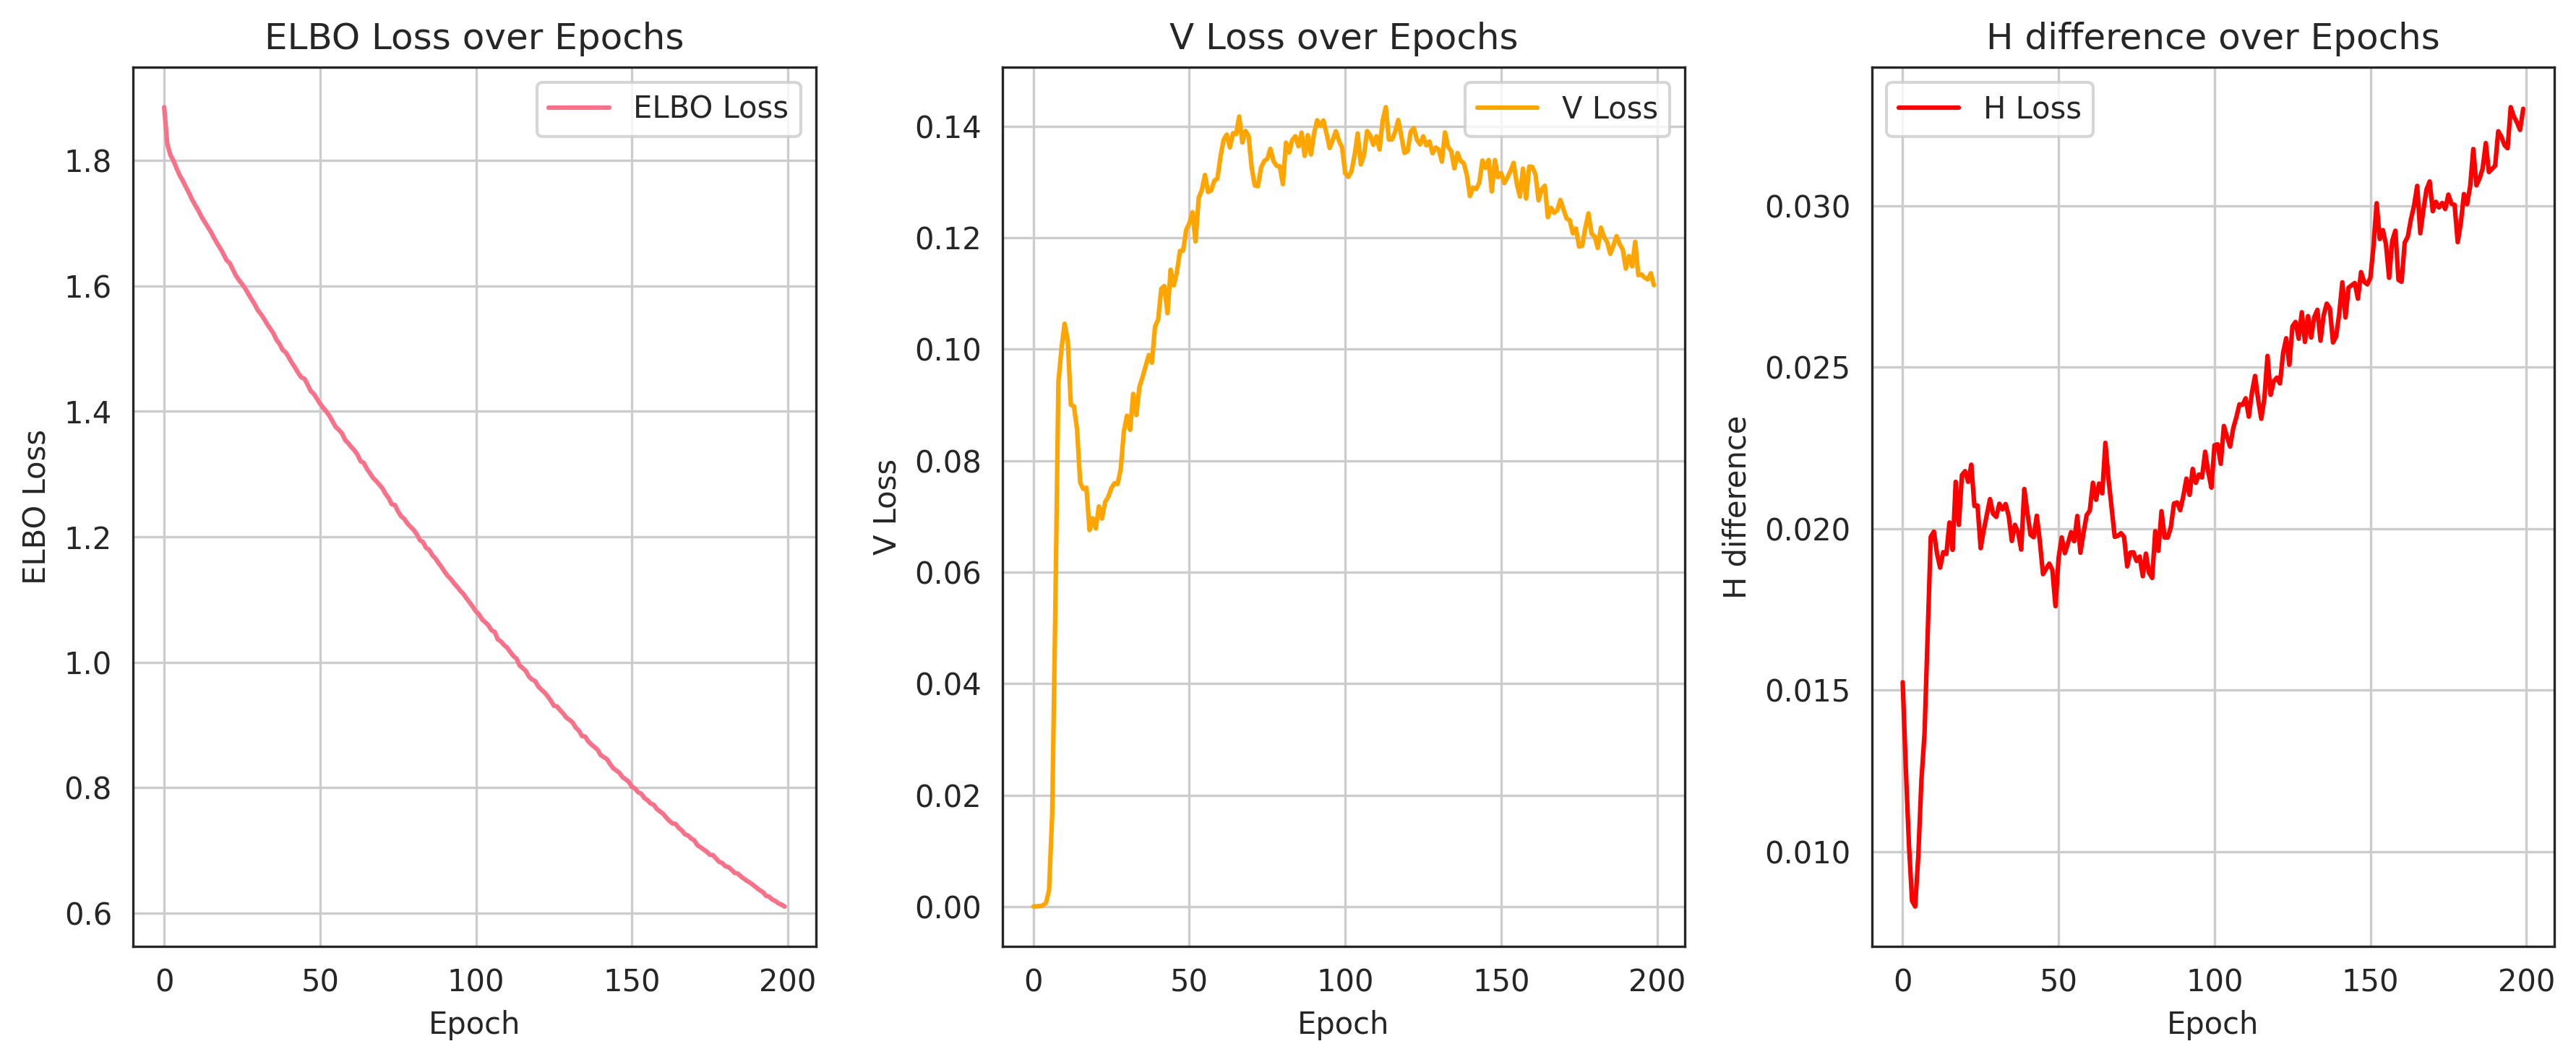


✓ Training completed successfully!


In [7]:
# Define model directory based on hyperparameters
model_dir = "../../BoneMarrow_model"

print("\nStarting model training...")
print("="*60)

# Clear parameter store for fresh training
pyro.clear_param_store()

# Create save directory
os.makedirs(model_dir, exist_ok=True)
num_epochs = 200
print(f"Training for {num_epochs} epochs")
print("This may take 20-30 minutes on GPU...")

# Train the model
lsd.train(
    num_epochs=num_epochs,
    save_dir=model_dir,
    save_interval=50,  # Save checkpoints every 20 epochs
    random_state=SEED
)

print("\n" + "="*60)
print("✓ Training completed successfully!")
print("="*60)